# CNN Classification Model to Investigate Cell Image Types

### Importing required libraries

In [1]:
import pickle
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision
import torchvision.transforms as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import numpy as np
from tqdm import tqdm
import seaborn as sns
import torchvision.models as models

### Setting up the GPU Device

In [2]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda:1


### Setting the seed for reproducibility

In [3]:
SEED = 35  # Random seed for reproducibility

In [4]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(False)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

## Data Preparation

### Extracting labels and determining number of classes

In [5]:
# Configuration

pkl_directory = "imaging/dataset_extraction/cell_dataset/" # The PKL Directory
TARGET_H, TARGET_W = 224, 224  # Target dimension of 224 for resizing images - it is the standard for ResNet
USE_GRAYSCALE = False  # Whether to use grayscale images
BATCH_SIZE = 64  # Batch size for training
NUM_WORKERS = 4

In [6]:
cell_labels = []
cell_images = []
cell_details = []
chip_names = []
for pkl_file in Path(pkl_directory).glob("*.pkl"):
   with open(pkl_file, "rb") as f:
      entry = pickle.load(f)

   cell_labels.extend(entry["labels"])
   cell_images.extend(entry["data"])
   cell_details.extend(entry["cell_details"])
   chip_names.extend([pkl_file.stem] * len(entry["labels"]))

In [7]:
cell_labels_array = np.asarray(cell_labels, dtype=np.int64)
num_classes = int(np.max(cell_labels)) + 1
print(f"Number of classes: {num_classes}")

Number of classes: 3


In [8]:
idx_0 = np.where(cell_labels_array == 0)[0]
idx_1 = np.where(cell_labels_array == 1)[0]
idx_2 = np.where(cell_labels_array == 2)[0]
target_n = min(len(idx_0), len(idx_1), len(idx_2))

rng = np.random.default_rng(SEED)
selected_idx_0 = rng.choice(idx_0, size=target_n, replace=False)
selected_idx_1 = rng.choice(idx_1, size=target_n, replace=False)
selected_idx_2 = rng.choice(idx_2, size=target_n, replace=False)

selected_indices = np.concatenate([selected_idx_0, selected_idx_1, selected_idx_2])
rng.shuffle(selected_indices)
X = [cell_images[i] for i in selected_indices]
y = cell_labels_array[selected_indices]
Cell_name_selected = [cell_details[i] for i in selected_indices]
Chip_name_selected = [chip_names[i] for i in selected_indices]

rejected_indexes = set(range(len(cell_labels_array))) - set(selected_indices)
leftover_images = [cell_images[j] for j in rejected_indexes]
leftover_labels = cell_labels_array[list(rejected_indexes)]
Cell_name_leftover = [cell_details[j] for j in rejected_indexes]
Chip_name_leftover = [chip_names[j] for j in rejected_indexes]

In [9]:
print(Counter(y))

Counter({np.int64(0): 6622, np.int64(1): 6622, np.int64(2): 6622})


In [10]:
print(f"Total samples after balancing: {len(X)}")
print(f"Total samples rejected: {len(leftover_labels)}")

Total samples after balancing: 19866
Total samples rejected: 226544


### Defining the Dataset class and Building the Dataset

In [11]:
class CellsDataset(Dataset):
    def __init__(self, images, labels, transform=None, grayscale=USE_GRAYSCALE):
        self.images = images
        self.labels = labels
        self.transform = transform

        base = []
        base += [T.ToPILImage()]
        base += [T.Resize((TARGET_H, TARGET_W), antialias=True)]
        
        if grayscale:
            base += [T.Grayscale(num_output_channels=1)]
        
        if self.transform:
            base += [
                T.RandomHorizontalFlip(p = 0.5),
                T.RandomVerticalFlip(p = 0.3),
            ]
        
        base += [T.ToTensor()]
        base += [T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])] # ImageNet normalization
        self.to_tensor = T.Compose(base)
    
        
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        if self.transform is not None:
            image = self.to_tensor(image)
        y = int(self.labels[idx])
        return image, y

In [12]:
# Stratified Split into Train, Validation, and Test Sets (Stratification helps maintain class distribution across splits)

idx = np.arange(len(y))
train_idx, temp_idx, y_train, y_temp = train_test_split(idx, y, test_size=0.3, random_state=SEED, stratify=y)
val_idx, test_idx, y_val, y_test = train_test_split(temp_idx, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

In [13]:
# Defining the datasets

train_dataset = CellsDataset(
    images=[X[i] for i in train_idx],
    labels=y_train,
    transform=True,
    grayscale=USE_GRAYSCALE
)

val_dataset = CellsDataset(
    images=[X[i] for i in val_idx],
    labels=y_val,
    transform=False,
    grayscale=USE_GRAYSCALE
)

test_dataset = CellsDataset(
    images=[X[i] for i in test_idx],
    labels=y_test,
    transform=False,
    grayscale=USE_GRAYSCALE
)

rejected_dataset = CellsDataset(
    images=leftover_images,
    labels=leftover_labels,
    transform=False,
    grayscale=USE_GRAYSCALE
)

In [14]:
# Using a WeightedRandomSampler to handle class imbalance in the training dataset
class_counts = Counter(y_train)
class_weights = torch.tensor([1.0 / class_counts[i] for i in range(num_classes)], dtype=torch.float)
sample_weights = torch.tensor([class_weights[label] for label in y_train], dtype=torch.float)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

In [15]:
print(class_counts)

Counter({np.int64(0): 4636, np.int64(1): 4635, np.int64(2): 4635})


In [16]:
# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

leftover_loader = DataLoader(rejected_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [17]:
print("Train Counts:", Counter(y_train))
print("Validation Counts:", Counter(y_val))
print("Test Counts:", Counter(y_test))
print("Leftover Counts:", Counter(leftover_labels))

Train Counts: Counter({np.int64(0): 4636, np.int64(1): 4635, np.int64(2): 4635})
Validation Counts: Counter({np.int64(1): 994, np.int64(0): 993, np.int64(2): 993})
Test Counts: Counter({np.int64(2): 994, np.int64(0): 993, np.int64(1): 993})
Leftover Counts: Counter({np.int64(2): 157606, np.int64(1): 68938})


## Model Definition

In [18]:
weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)

In [19]:
def print_metrics(y_true, y_pred, label=""):
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0, 1, 2])
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    print(f"\n{label} metrics:")
    for cls in [0, 1, 2]:
        tp = ((y_true == cls) & (y_pred == cls)).sum()
        fp = ((y_true != cls) & (y_pred == cls)).sum()
        fn = ((y_true == cls) & (y_pred != cls)).sum()
        print(f"Class {cls}:")
        print(f"  TP={tp}, FP={fp}, FN={fn}")
        print(f"  Precision = TP / (TP + FP) = {tp} / ({tp} + {fp}) = {precision[cls]:.4f}")
        print(f"  Recall    = TP / (TP + FN) = {tp} / ({tp} + {fn}) = {recall[cls]:.4f}")
        print(f"  F1        = 2 * (P*R)/(P+R) = 2*({precision[cls]:.4f}*{recall[cls]:.4f})/({precision[cls]:.4f}+{recall[cls]:.4f}) = {f1[cls]:.4f}")
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall:    {recall_macro:.4f}")
    print(f"Macro F1:        {f1_macro:.4f}")


In [20]:
def train_loop(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    running_loss, correct = 0.0, 0
    train_iter = tqdm(dataloader, desc=f"Epoch {epoch:03d} [Train]", leave=False)
    y_true_train, y_pred_train = [], []
    for inputs, labels in train_iter:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == labels).sum().item()
        y_true_train.extend(labels.cpu().numpy())
        y_pred_train.extend(pred.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)
    print(f"Train Loss: {epoch_loss[0]:.4f}, Accuracy: {epoch_loss[1]:.4f}")
    print(classification_report(y_true_train, y_pred_train))
    return epoch_loss

In [21]:
def validation_loop(model, dataloader, criterion, device, epoch):
    model.eval()
    running_loss, correct = 0.0, 0
    val_iter = tqdm(dataloader, desc=f"Epoch {epoch:03d} [Val]", leave=False)
    y_true_val, y_pred_val = [], []
    with torch.no_grad():
        for inputs, labels in val_iter:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            running_loss += loss.item() * labels.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == labels).sum().item()
            y_true_val.extend(labels.cpu().numpy())
            y_pred_val.extend(pred.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)
    print(f"Validation Loss: {epoch_loss[0]:.4f}, Accuracy: {epoch_loss[1]:.4f}")
    print(classification_report(y_true_val, y_pred_val))
    return epoch_loss

In [22]:
def test_loop(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct = 0.0, 0
    test_iter = tqdm(dataloader, desc=f"[Test]", leave=False)
    y_true_test, y_pred_test = [], []
    with torch.no_grad():
        for inputs, labels in test_iter:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            running_loss += loss.item() * labels.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == labels).sum().item()
            y_true_test.extend(labels.cpu().numpy())
            y_pred_test.extend(pred.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)
    print(f"Test Loss: {epoch_loss[0]:.4f}, Accuracy: {epoch_loss[1]:.4f}")
    print(classification_report(y_true_test, y_pred_test))
    print_metrics(np.array(y_true_test), np.array(y_pred_test), label="Test")
    
    sns.heatmap(confusion_matrix(y_true_test, y_pred_test), annot=True, fmt="d")
    plt.title('Confusion Matrix', fontsize=17, pad=20)
    plt.gca().xaxis.set_label_position('top') 
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.gca().xaxis.tick_top()
    plt.gca().figure.subplots_adjust(bottom=0.2)
    
    plt.show()
    return epoch_loss, y_true_test, y_pred_test

In [23]:
class EarlyStopping:
    def __init__(self, patience = 5, min_delta = 0.0, mode = 'max', restore_best_weights = True):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.restore_best_weights = restore_best_weights
        self.best_score = None
        self.counter = 0
        self.best_path = "ResNet_best_model.pth"
    
    def is_improved(self, current_score):
        if self.best_score is None:
            return True
        if self.mode == 'max':
            return current_score > self.best_score + self.min_delta
        else: # in the case of 'min'
            return current_score < self.best_score - self.min_delta
        
    def step(self, current_score, model):
        if self.is_improved(current_score):
            self.best_score = current_score
            self.counter = 0
            torch.save(model.state_dict(), self.best_path)
        else:
            self.counter += 1
            return self.counter >= self.patience
        
    def restore_weights(self, model, map_location=None):
        if self.restore_best_weights and self.best_score is not None:
            model.load_state_dict(torch.load(self.best_path, map_location=map_location))
        

## Using the Model

In [24]:
# Defining model, criterion, and optimizer
counts = torch.tensor([Counter(y_train)[i] for i in range(num_classes)], dtype=torch.float)
weights = (1.0 / counts).clamp(max = (1.0 / counts.min()))
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)

In [25]:
xb, yb = next(iter(train_loader))
print("Batch x shape:", xb.shape)
print("Batch y shape:", yb.shape)
print(model(xb.to(device)).shape)

Batch x shape: torch.Size([64, 3, 224, 224])
Batch y shape: torch.Size([64])
torch.Size([64, 3])


In [48]:
# TRAINING

EPOCHS = 50
best_val = -float('inf')
best_epoch = 0
stopper = EarlyStopping(patience=5, min_delta=1e-4, mode='max', restore_best_weights=True)

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")
    train_loss = train_loop(model, train_loader, criterion, optimizer, device, epoch)
    val_loss = validation_loop(model, val_loader, criterion, device, epoch)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss[0]:.4f}, Train Acc: {train_loss[1]:.4f} | Val Loss: {val_loss[0]:.4f}, Val Acc: {val_loss[1]:.4f}")

    if val_loss[1] > best_val:
        best_val = val_loss[1]
        best_epoch = epoch
        print(f"New best model found at epoch {epoch}")
    
    if stopper.step(val_loss[1], model):
        print(f"Early stopping at epoch {epoch}: Best epoch was {best_epoch} with validation accuracy {best_val:.4f}.")
        stopper.restore_weights(model, map_location=device)
        break
    
    
print(f"Training complete. Best validation accuracy: {best_val:.4f} at epoch {best_epoch}")

Epoch 1/50


Train Loss: 0.4005, Accuracy: 0.8207
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      4697
           1       0.75      0.71      0.73      4536
           2       0.78      0.78      0.78      4673

    accuracy                           0.82     13906
   macro avg       0.82      0.82      0.82     13906
weighted avg       0.82      0.82      0.82     13906



Validation Loss: 0.8508, Accuracy: 0.5638
              precision    recall  f1-score   support

           0       0.97      0.38      0.54       993
           1       0.43      0.91      0.58       994
           2       0.83      0.40      0.54       993

    accuracy                           0.56      2980
   macro avg       0.74      0.56      0.56      2980
weighted avg       0.74      0.56      0.56      2980

Epoch 01 | Train Loss: 0.4005, Train Acc: 0.8207 | Val Loss: 0.8508, Val Acc: 0.5638
New best model found at epoch 1
Epoch 2/50


Train Loss: 0.3010, Accuracy: 0.8610
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      4600
           1       0.81      0.78      0.79      4659
           2       0.82      0.83      0.82      4647

    accuracy                           0.86     13906
   macro avg       0.86      0.86      0.86     13906
weighted avg       0.86      0.86      0.86     13906



Validation Loss: 0.4251, Accuracy: 0.8064
              precision    recall  f1-score   support

           0       0.97      0.85      0.91       993
           1       0.68      0.81      0.74       994
           2       0.81      0.76      0.78       993

    accuracy                           0.81      2980
   macro avg       0.82      0.81      0.81      2980
weighted avg       0.82      0.81      0.81      2980

Epoch 02 | Train Loss: 0.3010, Train Acc: 0.8610 | Val Loss: 0.4251, Val Acc: 0.8064
New best model found at epoch 2
Epoch 3/50


...

Validation Loss: 0.3164, Accuracy: 0.8644
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       993
           1       0.81      0.79      0.80       994
           2       0.82      0.86      0.84       993

    accuracy                           0.86      2980
   macro avg       0.87      0.86      0.86      2980
weighted avg       0.87      0.86      0.86      2980

Epoch 08 | Train Loss: 0.2042, Train Acc: 0.9104 | Val Loss: 0.3164, Val Acc: 0.8644
Epoch 9/50


Train Loss: 0.1993, Accuracy: 0.9077
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4577
           1       0.87      0.85      0.86      4639
           2       0.87      0.89      0.88      4690

    accuracy                           0.91     13906
   macro avg       0.91      0.91      0.91     13906
weighted avg       0.91      0.91      0.91     13906



Validation Loss: 0.3285, Accuracy: 0.8507
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       993
           1       0.77      0.79      0.78       994
           2       0.82      0.82      0.82       993

    accuracy                           0.85      2980
   macro avg       0.85      0.85      0.85      2980
weighted avg       0.85      0.85      0.85      2980

Epoch 09 | Train Loss: 0.1993, Train Acc: 0.9077 | Val Loss: 0.3285, Val Acc: 0.8507
Epoch 10/50


Train Loss: 0.1928, Accuracy: 0.9137
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4750
           1       0.88      0.86      0.87      4581
           2       0.87      0.89      0.88      4575

    accuracy                           0.91     13906
   macro avg       0.91      0.91      0.91     13906
weighted avg       0.91      0.91      0.91     13906



Validation Loss: 0.2640, Accuracy: 0.8819
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       993
           1       0.82      0.83      0.82       994
           2       0.85      0.85      0.85       993

    accuracy                           0.88      2980
   macro avg       0.88      0.88      0.88      2980
weighted avg       0.88      0.88      0.88      2980

Epoch 10 | Train Loss: 0.1928, Train Acc: 0.9137 | Val Loss: 0.2640, Val Acc: 0.8819
Early stopping at epoch 10: Best epoch was 5 with validation accuracy 0.8849.
Training complete. Best validation accuracy: 0.8849 at epoch 5


Test Loss: 0.2478, Accuracy: 0.8899
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       993
           1       0.84      0.83      0.83       993
           2       0.87      0.85      0.86       994

    accuracy                           0.89      2980
   macro avg       0.89      0.89      0.89      2980
weighted avg       0.89      0.89      0.89      2980


Test metrics:
Class 0:
  TP=981, FP=42, FN=12
  Precision = TP / (TP + FP) = 981 / (981 + 42) = 0.9589
  Recall    = TP / (TP + FN) = 981 / (981 + 12) = 0.9879
  F1        = 2 * (P*R)/(P+R) = 2*(0.9589*0.9879)/(0.9589+0.9879) = 0.9732
Class 1:
  TP=822, FP=154, FN=171
  Precision = TP / (TP + FP) = 822 / (822 + 154) = 0.8422
  Recall    = TP / (TP + FN) = 822 / (822 + 171) = 0.8278
  F1        = 2 * (P*R)/(P+R) = 2*(0.8422*0.8278)/(0.8422+0.8278) = 0.8349
Class 2:
  TP=849, FP=132, FN=145
  Precision = TP / (TP + FP) = 849 / (849 + 132) = 0.8654
  Recall    = TP / (TP + FN) =

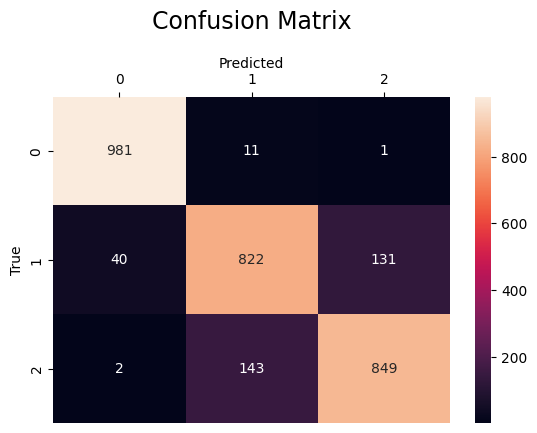

Test Loss: 0.2478, Test Accuracy: 0.8899


In [26]:
# Load the best model for testing

model.load_state_dict(torch.load("ResNet_best_model.pth"))
test_loss, y_true_test, y_pred_test = test_loop(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss[0]:.4f}, Test Accuracy: {test_loss[1]:.4f}")

Test Loss: 0.2097, Accuracy: 0.9049
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4697
           1       0.86      0.85      0.85      4537
           2       0.89      0.87      0.88      4672

    accuracy                           0.90     13906
   macro avg       0.90      0.90      0.90     13906
weighted avg       0.90      0.90      0.90     13906


Test metrics:
Class 0:
  TP=4681, FP=174, FN=16
  Precision = TP / (TP + FP) = 4681 / (4681 + 174) = 0.9642
  Recall    = TP / (TP + FN) = 4681 / (4681 + 16) = 0.9966
  F1        = 2 * (P*R)/(P+R) = 2*(0.9642*0.9966)/(0.9642+0.9966) = 0.9801
Class 1:
  TP=3843, FP=624, FN=694
  Precision = TP / (TP + FP) = 3843 / (3843 + 624) = 0.8603
  Recall    = TP / (TP + FN) = 3843 / (3843 + 694) = 0.8470
  F1        = 2 * (P*R)/(P+R) = 2*(0.8603*0.8470)/(0.8603+0.8470) = 0.8536
Class 2:
  TP=4060, FP=524, FN=612
  Precision = TP / (TP + FP) = 4060 / (4060 + 524) = 0.8857
  Recall    = T

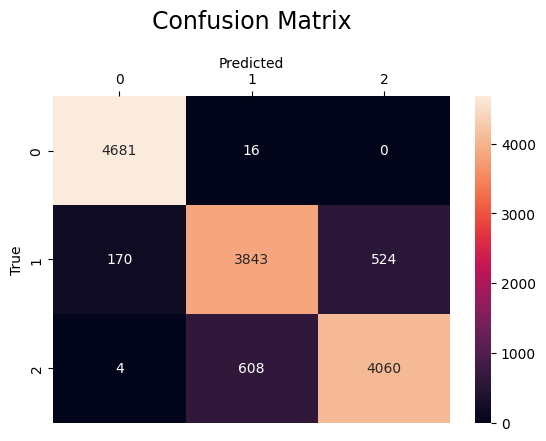

Train Loss: 0.2097, Train Accuracy: 0.9049


In [27]:
# Load the best model for testing

model.load_state_dict(torch.load("ResNet_best_model.pth"))
train_loss, y_true_train, y_pred_train = test_loop(model, train_loader, criterion, device)
print(f"Train Loss: {train_loss[0]:.4f}, Train Accuracy: {train_loss[1]:.4f}")

Test Loss: 0.2555, Accuracy: 0.8849
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       993
           1       0.84      0.81      0.83       994
           2       0.85      0.86      0.85       993

    accuracy                           0.88      2980
   macro avg       0.88      0.88      0.88      2980
weighted avg       0.88      0.88      0.88      2980


Test metrics:
Class 0:
  TP=983, FP=42, FN=10
  Precision = TP / (TP + FP) = 983 / (983 + 42) = 0.9590
  Recall    = TP / (TP + FN) = 983 / (983 + 10) = 0.9899
  F1        = 2 * (P*R)/(P+R) = 2*(0.9590*0.9899)/(0.9590+0.9899) = 0.9742
Class 1:
  TP=804, FP=151, FN=190
  Precision = TP / (TP + FP) = 804 / (804 + 151) = 0.8419
  Recall    = TP / (TP + FN) = 804 / (804 + 190) = 0.8089
  F1        = 2 * (P*R)/(P+R) = 2*(0.8419*0.8089)/(0.8419+0.8089) = 0.8250
Class 2:
  TP=850, FP=150, FN=143
  Precision = TP / (TP + FP) = 850 / (850 + 150) = 0.8500
  Recall    = TP / (TP + FN) =

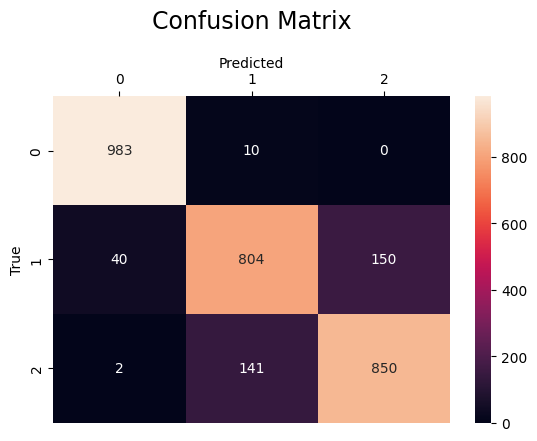

Validation Loss: 0.2555, Validation Accuracy: 0.8849


In [28]:
# Load the best model for testing

model.load_state_dict(torch.load("ResNet_best_model.pth"))
val_loss, y_true_val, y_pred_val = test_loop(model, val_loader, criterion, device)
print(f"Validation Loss: {val_loss[0]:.4f}, Validation Accuracy: {val_loss[1]:.4f}")

/home/kakuly/iris-layout/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kakuly/iris-layout/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kakuly/iris-layout/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/

Test Loss: 0.3306, Accuracy: 0.8410
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.71      0.82      0.76     68938
           2       0.93      0.85      0.89    157606

    accuracy                           0.84    226544
   macro avg       0.55      0.56      0.55    226544
weighted avg       0.86      0.84      0.85    226544


Test metrics:
Class 0:
  TP=0, FP=2981, FN=0
  Precision = TP / (TP + FP) = 0 / (0 + 2981) = 0.0000
  Recall    = TP / (TP + FN) = 0 / (0 + 0) = 0.0000
  F1        = 2 * (P*R)/(P+R) = 2*(0.0000*0.0000)/(0.0000+0.0000) = 0.0000
Class 1:
  TP=56631, FP=23518, FN=12307
  Precision = TP / (TP + FP) = 56631 / (56631 + 23518) = 0.7066
  Recall    = TP / (TP + FN) = 56631 / (56631 + 12307) = 0.8215
  F1        = 2 * (P*R)/(P+R) = 2*(0.7066*0.8215)/(0.7066+0.8215) = 0.7597
Class 2:
  TP=133886, FP=9528, FN=23720
  Precision = TP / (TP + FP) = 133886 / (133886 + 9528) = 0.9336
  Recal

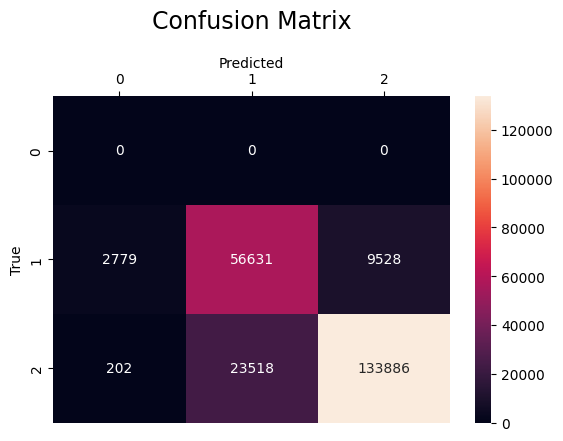

Loss on rejected images: 0.3306, Accuracy on rejected images: 0.8410


In [25]:
rejected_loss, reject_true, reject_pred = test_loop(model, leftover_loader, criterion, device)
print(f"Loss on rejected images: {rejected_loss[0]:.4f}, Accuracy on rejected images: {rejected_loss[1]:.4f}")

In [89]:
# THE COLOURS ARE IN BGR
COLOR2ID = {
    0: (255, 0, 0),  # blue (flipflop) 
    1: (0, 255, 0),  # green (logic)
    2: (0, 0, 255),  # red (filler)
}

In [ ]:
# THE COLOURS ARE IN BGR
EA_COLOUR = {
    "01": (255, 150, 200),  
    "10": (150, 255, 200),  # DULL GREEN
    "02": (200, 150, 255),  
    "20": (0, 255, 255),
    "12": (255, 0, 255), # HOT PINK
    "21": (255, 255, 0), # CYAN
}

In [91]:
from collections import defaultdict
index_misclassified = []
for i in range(len(y_true_test)):
    if y_true_test[i] != y_pred_test[i]:
        index_misclassified.append(i)

stats = defaultdict(list)
errored_cell_names = defaultdict(list)
wrong_predictions = defaultdict(list)
for val in index_misclassified:
    original_index = test_idx[val]
    stats[y_test[val]].append(X[original_index])
    errored_cell_names[Chip_name_selected[original_index]].append(f"{y_true_test[val]}{y_pred_test[val]}")
    wrong_predictions[Chip_name_selected[original_index]].append(Cell_name_selected[original_index])

In [92]:
for key in stats:
    print(f"Class {key} - Number of misclassified samples: {len(stats[key])}")

Class 2 - Number of misclassified samples: 145
Class 1 - Number of misclassified samples: 171
Class 0 - Number of misclassified samples: 12


In [93]:
print(Chip_name_selected[0])

wrapped_mbsFSK_poly_cell_1


In [94]:
for chip, cells in wrong_predictions.items():
    print(f"Processing chip: {chip} with {len(cells)} misclassified cells")
    chip_name = chip.replace("_poly_cell_1", "_cropped")
    gds_label_image = cv2.imread(f"imaging/data_cropped_images/{chip_name}.png", cv2.IMREAD_COLOR_BGR)
    for cell in cells:
        values = cell.split('_')
        x1 = int(values[0])
        y1 = int(values[1])
        x2 = int(values[2])
        y2 = int(values[3])
        cv2.rectangle(gds_label_image, (x1, y1), (x2, y2), COLOR2ID[int(values[-1])], -1)
    cv2.imwrite(f"analysis/misclassified_{chip_name}.png", gds_label_image)


Processing chip: wrapped_silife_poly_cell_1 with 185 misclassified cells
Processing chip: wrapped_mbsFSK_poly_cell_1 with 11 misclassified cells
Processing chip: housekeeping_poly_cell_1 with 30 misclassified cells
Processing chip: wrapped_ibnalhaytham_poly_cell_1 with 37 misclassified cells
Processing chip: wrapped_etpu_poly_cell_1 with 36 misclassified cells
Processing chip: wrapped_snn_network_poly_cell_1 with 11 misclassified cells
Processing chip: wb_openram_wrapper_poly_cell_1 with 8 misclassified cells
Processing chip: wrapped_function_generator_poly_cell_1 with 7 misclassified cells
Processing chip: wb_bridge_2way_poly_cell_1 with 3 misclassified cells


In [95]:
for chip, cells in wrong_predictions.items():
    print(f"Processing chip: {chip} with {len(cells)} misclassified cells")
    chip_name = chip.replace("_poly_cell_1", "_cropped")
    gds_label_image = cv2.imread(f"imaging/data_cropped_images/{chip_name}.png", cv2.IMREAD_COLOR_BGR)
    
    for idx, cell in enumerate(cells):
        colour = EA_COLOUR[str(errored_cell_names[chip][idx])]
        values = cell.split('_')
        x1 = int(values[0])
        y1 = int(values[1])
        x2 = int(values[2])
        y2 = int(values[3])
        cv2.rectangle(gds_label_image, (x1, y1), (x2, y2), colour, -1)
    cv2.imwrite(f"error_analysis/misclassified_{chip_name}.png", gds_label_image)

Processing chip: wrapped_silife_poly_cell_1 with 185 misclassified cells
Processing chip: wrapped_mbsFSK_poly_cell_1 with 11 misclassified cells
Processing chip: housekeeping_poly_cell_1 with 30 misclassified cells
Processing chip: wrapped_ibnalhaytham_poly_cell_1 with 37 misclassified cells
Processing chip: wrapped_etpu_poly_cell_1 with 36 misclassified cells
Processing chip: wrapped_snn_network_poly_cell_1 with 11 misclassified cells
Processing chip: wb_openram_wrapper_poly_cell_1 with 8 misclassified cells
Processing chip: wrapped_function_generator_poly_cell_1 with 7 misclassified cells
Processing chip: wb_bridge_2way_poly_cell_1 with 3 misclassified cells


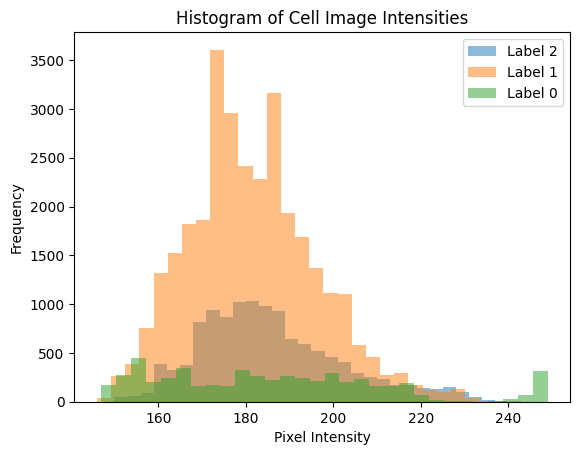

In [96]:
for label, images in stats.items():
   rgb_pixels = np.concatenate([im.reshape(-1, 3) for im in images], axis=0)
   gray= np.mean(rgb_pixels, axis = 1)
   plt.hist(gray, bins=30, alpha=0.5, label=f"Label {label}")

plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Histogram of Cell Image Intensities")
plt.legend()
plt.show()

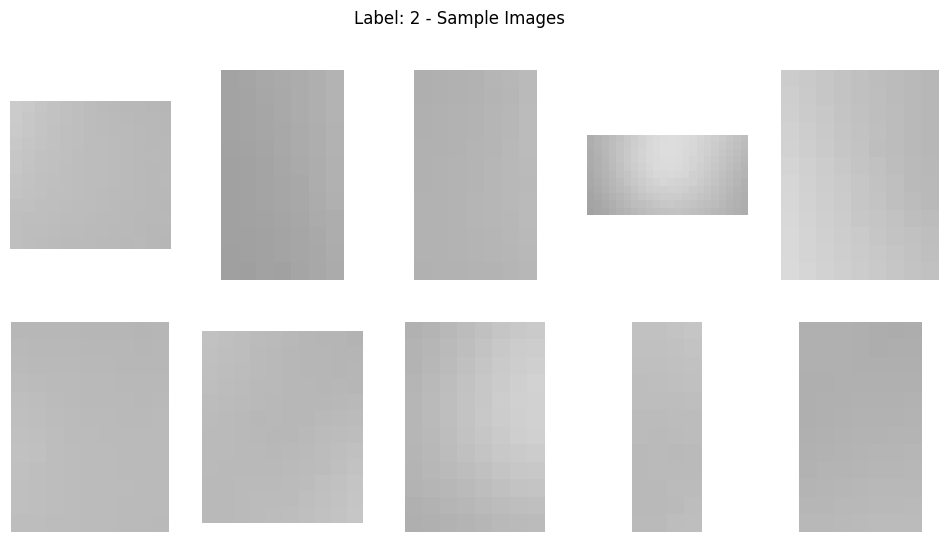

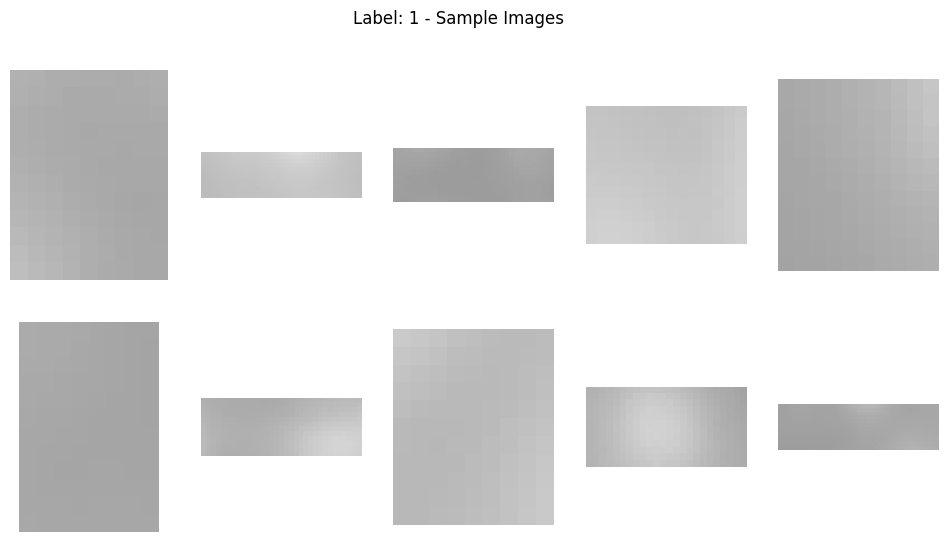

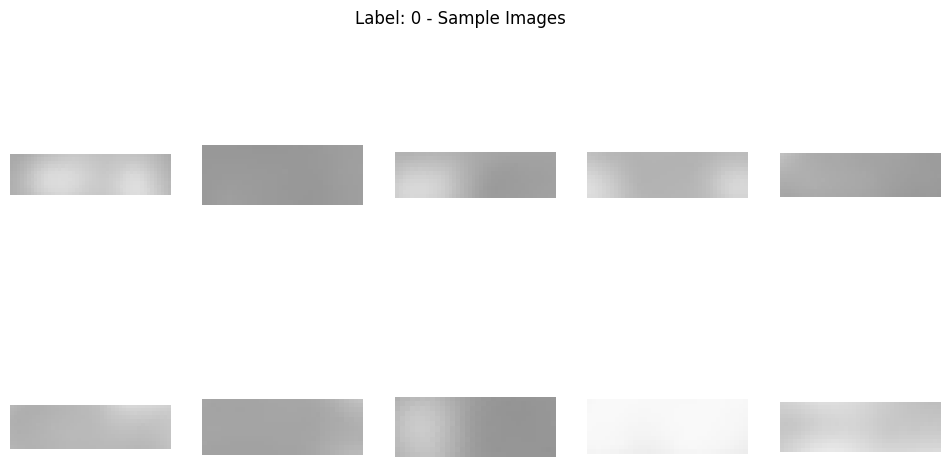

In [97]:
for label, images in stats.items():
    plt.figure(figsize=(12, 6))
    for i, image in enumerate(images[:10]):
        plt.subplot(2, 5, i + 1)
        plt.imshow(image)
        plt.axis('off')
    plt.suptitle(f'Label: {label} - Sample Images')
    plt.show()

In [98]:
index_misclassified = []
for i in range(len(reject_true)):
    if reject_true[i] != reject_pred[i]:
        index_misclassified.append(i)

stats = defaultdict(list)
errored_cell_names = defaultdict(list)
wrong_predictions_2 = defaultdict(list)
for val in index_misclassified:
    stats[leftover_labels[val]].append(leftover_images[val])
    errored_cell_names[Chip_name_leftover[val]].append(f"{reject_true[val]}{reject_pred[val]}")
    wrong_predictions_2[Chip_name_leftover[val]].append(Cell_name_leftover[val])

In [99]:
print(Chip_name_leftover[0])

wrapped_function_generator_poly_cell_1


In [100]:
print(wrong_predictions_2["wrapped_function_generator_poly_cell_1"])

['567_168_574_180_sky130_fd_sc_hd__decap_4_2', '565_194_572_206_sky130_fd_sc_hd__or2_1_1', '553_350_567_362_sky130_fd_sc_hd__mux2_1_1', '0_557_5_569_sky130_fd_sc_hd__decap_3_2', '176_557_186_569_sky130_fd_sc_hd__decap_6_2', '267_557_274_569_sky130_fd_sc_hd__decap_4_2', '313_557_320_569_sky130_fd_sc_hd__decap_4_2', '394_557_401_569_sky130_fd_sc_hd__decap_4_2', '383_557_391_569_sky130_fd_sc_hd__or2_1_1', '567_557_574_569_sky130_fd_sc_hd__decap_4_2', '737_557_769_569_sky130_fd_sc_hd__buf_12_1', '971_557_979_569_sky130_fd_sc_hd__decap_4_2', '1123_557_1127_569_sky130_fd_sc_hd__decap_3_2', '534_997_566_1009_sky130_fd_sc_hd__buf_12_1', '562_1010_603_1021_sky130_fd_sc_hd__clkbuf_16_1', '534_1022_566_1034_sky130_fd_sc_hd__buf_12_1', '560_1048_601_1060_sky130_fd_sc_hd__clkbuf_16_1', '561_1100_571_1112_sky130_fd_sc_hd__decap_6_2', '834_647_877_659_sky130_fd_sc_hd__ebufn_8_1', '738_841_742_853_sky130_fd_sc_hd__decap_3_2', '1123_841_1127_853_sky130_fd_sc_hd__decap_3_2', '1074_984_1118_996_sky130_fd

In [101]:
for chip, cells in wrong_predictions_2.items():
    print(f"Processing chip: {chip} with {len(cells)} misclassified cells")
    chip_name = chip.replace("_poly_cell_1", "_cropped")
    gds_label_image = cv2.imread(f"analysis/misclassified_{chip_name}.png", cv2.IMREAD_COLOR_BGR)
    for cell in cells:
        values = cell.split('_')
        x1 = int(values[0])
        y1 = int(values[1])
        x2 = int(values[2])
        y2 = int(values[3])
        cv2.rectangle(gds_label_image, (x1, y1), (x2, y2), COLOR2ID[int(values[-1])], -1)
    cv2.imwrite(f"analysis/misclassified_{chip_name}.png", gds_label_image)


Processing chip: wrapped_function_generator_poly_cell_1 with 644 misclassified cells
Processing chip: wrapped_snn_network_poly_cell_1 with 1086 misclassified cells
Processing chip: wrapped_ibnalhaytham_poly_cell_1 with 4041 misclassified cells
Processing chip: wrapped_mbsFSK_poly_cell_1 with 852 misclassified cells
Processing chip: wrapped_silife_poly_cell_1 with 20838 misclassified cells
Processing chip: housekeeping_poly_cell_1 with 2500 misclassified cells
Processing chip: wb_openram_wrapper_poly_cell_1 with 987 misclassified cells
Processing chip: wrapped_etpu_poly_cell_1 with 4536 misclassified cells
Processing chip: wb_bridge_2way_poly_cell_1 with 543 misclassified cells


In [102]:
for chip, cells in wrong_predictions_2.items():
    print(f"Processing chip: {chip} with {len(cells)} misclassified cells")
    chip_name = chip.replace("_poly_cell_1", "_cropped")
    gds_label_image = cv2.imread(f"error_analysis/misclassified_{chip_name}.png", cv2.IMREAD_COLOR_BGR)
    
    for idx, cell in enumerate(cells):
        colour = EA_COLOUR[str(errored_cell_names[chip][idx])]
        values = cell.split('_')
        x1 = int(values[0])
        y1 = int(values[1])
        x2 = int(values[2])
        y2 = int(values[3])
        cv2.rectangle(gds_label_image, (x1, y1), (x2, y2), colour, -1)
    cv2.imwrite(f"error_analysis/misclassified_{chip_name}.png", gds_label_image)

Processing chip: wrapped_function_generator_poly_cell_1 with 644 misclassified cells
Processing chip: wrapped_snn_network_poly_cell_1 with 1086 misclassified cells
Processing chip: wrapped_ibnalhaytham_poly_cell_1 with 4041 misclassified cells
Processing chip: wrapped_mbsFSK_poly_cell_1 with 852 misclassified cells
Processing chip: wrapped_silife_poly_cell_1 with 20838 misclassified cells
Processing chip: housekeeping_poly_cell_1 with 2500 misclassified cells
Processing chip: wb_openram_wrapper_poly_cell_1 with 987 misclassified cells
Processing chip: wrapped_etpu_poly_cell_1 with 4536 misclassified cells
Processing chip: wb_bridge_2way_poly_cell_1 with 543 misclassified cells


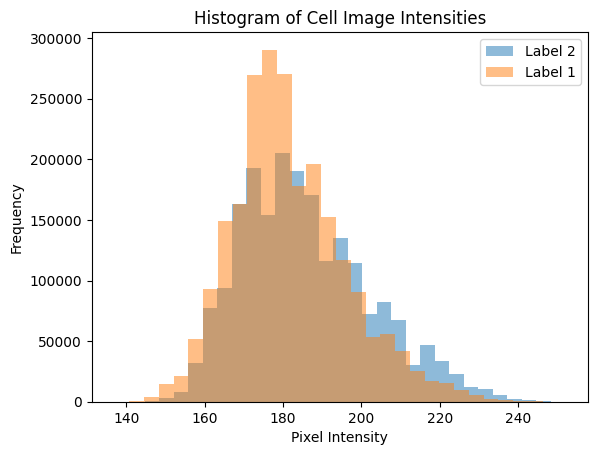

In [103]:
for label, images in stats.items():
   rgb_pixels = np.concatenate([im.reshape(-1, 3) for im in images], axis=0)
   gray= np.mean(rgb_pixels, axis = 1)
   plt.hist(gray, bins=30, alpha=0.5, label=f"Label {label}")

plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Histogram of Cell Image Intensities")
plt.legend()
plt.show()

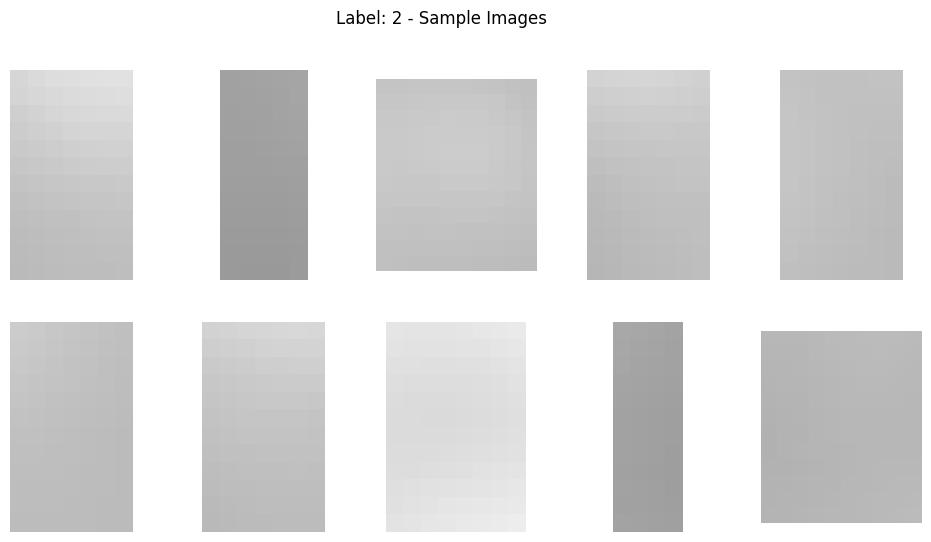

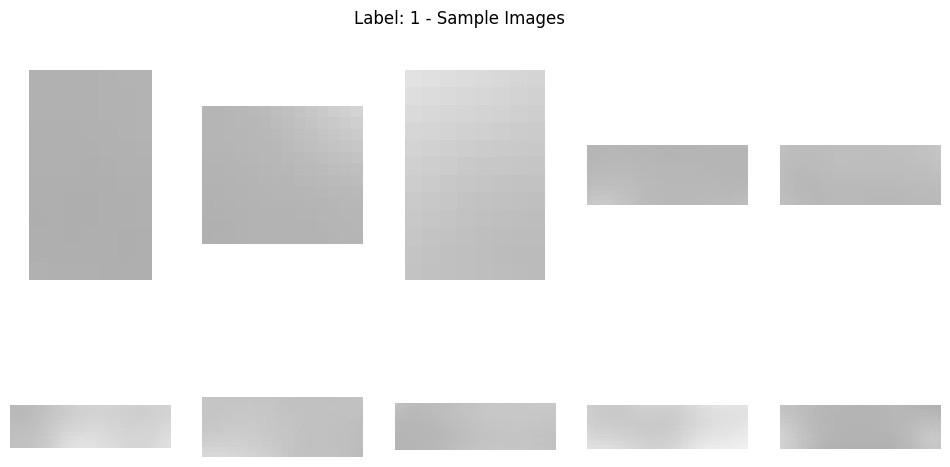

In [104]:
for label, images in stats.items():
    plt.figure(figsize=(12, 6))
    for i, image in enumerate(images[:10]):
        plt.subplot(2, 5, i + 1)
        plt.imshow(image)
        plt.axis('off')
    plt.suptitle(f'Label: {label} - Sample Images')
    plt.show()